# Record and change a pretrained image model

Run a normal model, silence one part, and check that it returns to normal. Brain-Score records the inputs, predictions, and internal activity.

**CPU only.** The first run downloads ResNet-18's pretrained weights (about 45 MB). Use the [UMI environment](../install/README.md) with Jupyter and matplotlib. Run the cells in order.

We use two real photographs bundled with scikit-learn. This is a tool demonstration, not an accuracy benchmark.


In [1]:
from contextlib import contextmanager
from pathlib import Path
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from sklearn.datasets import load_sample_images
from torchvision.models import resnet18, ResNet18_Weights

# Brain-Score needs a subject: the model it will send inputs to.
from brainscore_core.model_interface import Subject
# Sessions hold the exchange; events carry each input or response.
from brainscore_core.streaming import InMemorySession, StreamEvent
# These tools organize the run, save measurements, and change selected model parts.
from brainscore.experiments import (
    Experiment, SessionProtocol, RecordInputsOutputs, RecordActivity,
    Ablate, TorchInstrumentation, replay_sessions, compare_outputs,
)

# A fresh folder prevents reruns from overwriting previous recordings.
output_folder = Path(tempfile.mkdtemp(prefix='umi-resnet-demo-'))
print('Recordings will be saved in:', output_folder)


Recordings will be saved in: /var/folders/h6/g53mxg516n538136hh74630r0000gn/T/umi-resnet-demo-503uh8ud


## 1. Load the model and photographs

`eval()` switches off training behavior. The supplied image transform resizes, center-crops, and normalizes each photo exactly as the pretrained model expects.

The pictures below are the original photographs; the model receives their standardized center crops.


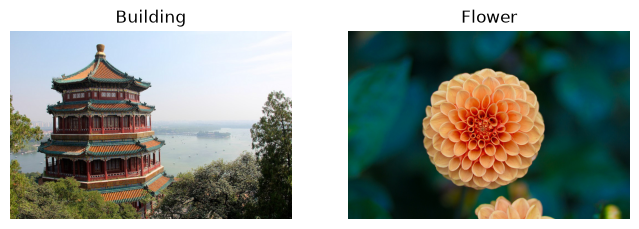

In [2]:
weights = ResNet18_Weights.IMAGENET1K_V1
model = resnet18(weights=weights).cpu().eval()
preprocess = weights.transforms()
class_names = weights.meta['categories']

photos = load_sample_images().images
# stack combines the two preprocessed images into one batch.
images = torch.stack([preprocess(Image.fromarray(photo)) for photo in photos])

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for ax, photo, name in zip(axes, photos, ['Building', 'Flower']):
    ax.imshow(photo)
    ax.set_title(name)
    ax.axis('off')
plt.show()


## 2. Connect it to a session

This short adapter tells Brain-Score how to send images to the model and return its predictions. `inference_mode()` turns off gradient tracking because we are measuring, not training. `softmax()` converts model scores into category probabilities.

- **`InMemorySession`** holds our already-loaded images and collects responses.
- **`SessionProtocol`** schedules the conditions: normal, silenced, and restored. Each has one trial by default.
- **`@contextmanager`** is Python's setup/cleanup helper. Here, it supplies a session inside the runner's managed scope. `yield` hands that session to the runner.


In [3]:
# Connect an ordinary PyTorch model to Brain-Score.
class ImageSubject(Subject):
    # A name for this model in the saved records.
    identifier = 'resnet18'
    # The kind of input this subject accepts.
    in_channels = {'image'}
    # The kind of response this subject returns.
    out_channels = {'prediction'}

    def __init__(self, model):
        self.model = model

    # Receive inputs and return predictions until the session ends.
    def interact(self, session):
        # Ask the session for its first input; None means the session is finished.
        event = session.next_input()
        while event is not None:
            with torch.inference_mode():
                pixels = torch.from_numpy(event.payload)
                probabilities = self.model(pixels).softmax(dim=1).numpy()
            # Send probabilities back with the input's experiment timestamp.
            session.emit(StreamEvent('prediction', probabilities, event.t_ms))
            event = session.next_input()

# The experiment talks to this adapter; the underlying model stays unchanged.
subject = ImageSubject(model)

@contextmanager
def make_session(trial):
    # Each condition receives an independent copy of the same images.
    # Hold the inputs in memory; time zero labels this presentation.
    yield InMemorySession([StreamEvent('image', images.numpy().copy(), t_ms=0)])

# Schedule the conditions and reset the subject between them.
protocol = SessionProtocol(
    'compare-conditions', make_session,
    # Run these conditions in order, using the same inputs.
    conditions=['normal', 'silenced', 'restored'],
    # Check that the session and subject agree on inputs and outputs.
    input_channels=['image'], output_channels=['prediction'],
)


## 3. Choose the tools and run

ResNet adds a learned update to a shortcut. `layer3.0.bn2` produces one such update; silencing it leaves the shortcut intact. `layer3.0` names the whole block. These are the model's own layer paths, used throughout UMI.

The ablation applies only to the silenced condition. `RecordActivity` measures after the change. Tools detach after each trial.


In [4]:
# Assemble the model, schedule, tools, and output location.
experiment = Experiment(
    subject=subject,  # The model adapter to run.
    protocol=protocol,  # The conditions and inputs to present.
    tools=[
        RecordInputsOutputs(),  # Save what the model receives and returns.
        Ablate(['layer3.0.bn2'], conditions=['silenced']),  # Zero this branch only in this condition.
        RecordActivity(['layer3.0.bn2', 'layer3.0']),  # Save internal responses after the change.
    ],
    instrumentation=TorchInstrumentation(model),  # Expose the model's actual layer paths to the tools.
    output_dir=output_folder / 'experiment',  # Save this run in a new folder.
    metadata={'weights': str(weights), 'device': 'cpu'},  # Keep the model setup with the results.
)
experiment.validate()  # Check that the selected subject, protocol, and tools fit together.
result = experiment.run()  # Attach tools, run all conditions, save results, then remove tools.
print(result.manifest['status'])


complete


## 4. Read what happened

Everything below comes from saved records. No additional inference is needed to inspect the results.

`argmax()` finds the category with the highest probability. These probabilities are model predictions, not correctness scores. The normal model can already be wrong—for example, the saved run calls the flower “honeycomb.”


In [5]:
predictions = {}
activity = {}
# Read saved measurements; this does not call the model again.
for event in result.record.events():
    condition = event['condition']  # Which condition produced this measurement?
    if event['kind'] == 'output':  # A prediction returned by the model.
        predictions[condition] = event['payload'].payload
    if event['kind'] == 'activity':  # A measurement from inside a selected module.
        target = event['payload']['target']
        activity[condition, target] = event['payload']['value']['array']

rows = []
for condition, probabilities in predictions.items():
    for name, values in zip(['Building', 'Flower'], probabilities):
        best = values.argmax()
        rows.append({
            'Photo': name,
            'Condition': condition,
            'Top prediction': class_names[best],
            'Probability (%)': round(float(values[best]) * 100, 1),
        })
pd.DataFrame(rows)


,Photo,Condition,Top prediction,Probability (%)
0,Building,normal,bell cote,53.6
1,Flower,normal,honeycomb,66.3
2,Building,silenced,laptop,59.0
3,Flower,silenced,laptop,14.0
4,Building,restored,bell cote,53.6
5,Flower,restored,honeycomb,66.3


### Compare the recorded activity

The height of each bar is the mean absolute activity across both images, channels, and spatial positions. The plots summarize measured values, not simulated or illustrative brain responses.

The selected branch should become zero. The block output can remain active through its shortcut. Each panel has its own labeled scale.


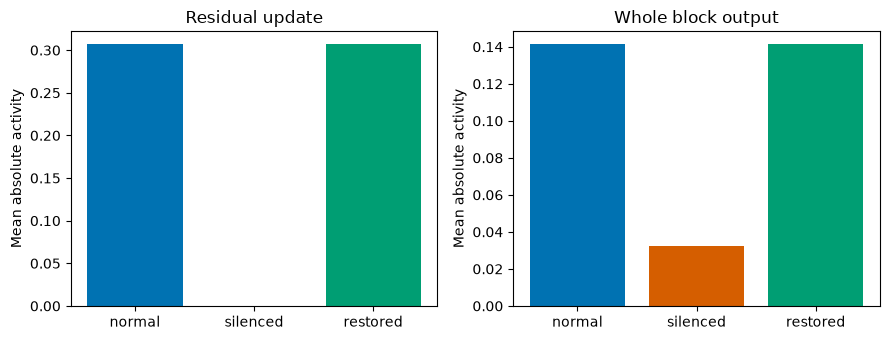

Verified: branch silenced, block still active, original predictions restored.


In [6]:
conditions = ['normal', 'silenced', 'restored']
colors = ['#0072B2', '#D55E00', '#009E73']
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, target in zip(axes, ['layer3.0.bn2', 'layer3.0']):
    values = [np.abs(activity[condition, target]).mean() for condition in conditions]
    ax.bar(conditions, values, color=colors)
    ax.set_title('Residual update' if target.endswith('bn2') else 'Whole block output')
    ax.set_ylabel('Mean absolute activity')
fig.tight_layout()
plt.show()

# These checks raise an error if the intervention or its cleanup failed.
assert np.count_nonzero(activity['silenced', 'layer3.0.bn2']) == 0
assert np.count_nonzero(activity['silenced', 'layer3.0']) > 0
np.testing.assert_array_equal(predictions['normal'], predictions['restored'])
# PyTorch keeps temporary callbacks here; an empty registry confirms cleanup.
for module in [model.layer3[0].bn2, model.layer3[0]]:
    assert not module._forward_hooks
print('Verified: branch silenced, block still active, original predictions restored.')


## 5. Replay the same inputs

Reattach the intervention explicitly, then send the recorded inputs through the model again. Replay does not silently apply tools from saved settings.


In [7]:
# Start a separate run using the saved inputs.
replay = Experiment(
    subject=subject,  # The model adapter to run.
    protocol=replay_sessions(result.directory),  # Reuse the original inputs and condition names.
    # Record again and explicitly repeat the intervention; replay does not attach it automatically.
    tools=[RecordInputsOutputs(), Ablate(['layer3.0.bn2'], conditions=['silenced'])],
    instrumentation=TorchInstrumentation(model),  # Expose the model's actual layer paths to the tools.
    output_dir=output_folder / 'replay',
).run()

# Check whether the two runs returned exactly the same outputs.
comparison = compare_outputs(result.directory, replay.directory)
assert comparison['equal'], comparison
print('Exact replay:', comparison['equal'])
print('Saved experiment:', result.directory)


Exact replay: True
Saved experiment: /var/folders/h6/g53mxg516n538136hh74630r0000gn/T/umi-resnet-demo-503uh8ud/experiment


## Take it further

Replace the photographs, change the selected module, or add another tool. Keep the same `Experiment` setup. Start a new output folder for each experiment.

This small demonstration does not establish accuracy, biological similarity, or what a layer “means.” The intervention changes one computational component and measures the consequences.

[Tool guide](../docs/experiment_toolbox.md) · [ResNet-18 checkpoint](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.resnet18.html)

**Photo credits:** scikit-learn's `china.jpg` by [danielbuechele](https://www.flickr.com/photos/danielbuechele/6061409035/) and `flower.jpg` by [vultilion](https://www.flickr.com/photos/vultilion/6056698931/), distributed under [CC BY 2.0](https://creativecommons.org/licenses/by/2.0/). The model uses resized, center-cropped versions.


[Notebook guide](README.md) · [Shared vocabulary](../docs/conventions.md)
